# Options 3: The Black-Scholes Model

This notebook introduces the Black-Scholes option pricing model. It also discusses *(a)* implied volatility; *(b)* how to calculate the Black-Scholes model by numerical integration and *(c)* how the binomial model converges to the Black-Scholes model.

## Load Packages and Extra Functions

In [1]:
using Printf, Distributions, Roots, QuadGK

include("src/printmat.jl");

In [2]:
using Plots, LaTeXStrings
default(size = (480,320),fmt = :png)

# Black-Scholes

The Black-Scholes formula for a European call option on an (underlying) asset with a continuous dividend rate $\delta$ is

$C  =e^{-\delta m}S\Phi(d_{1}) - e^{-ym}K\Phi(d_{2})$, where

$d_{1} =\frac{\ln(S/K)+(y-\delta+\sigma^{2}/2)m}{\sigma\sqrt{m}} \ \text{ and } \ d_{2}=d_{1}-\sigma\sqrt{m}$ 

and where $\Phi(d)$ denotes the probability of $x\leq d$ when $x$ has an $N(0,1)$ distribution. In other words, $\Phi(d)$ is the cumulative distribution function of the $N(0,1)$ distribution.

### A Remark on the Code

- `Φ(x)= cdf(Normal(0,1),x)` is a one-line definition of a function.

- The `;isPut=false` creates a keyword argument which defaults to `false` which means that we calculate a call option price. To calculate a put option price, use the function as `OptionBlackSPs(...;isPut=true)`.

In [3]:
"""
    Φ(x)
Calculate Pr(z<=x) for N(0,1) variable z. Convenient short hand notation. Used in `OptionBlackSPs()`.
"""
Φ(x)= cdf(Normal(0,1),x)


"""
Calculate Black-Scholes European call or put option price, continuous dividends of δ
"""
function OptionBlackSPs(S,K,m,y,σ,δ=0;isPut=false)
    d1 = ( log(S/K) + (y-δ+0.5*σ^2)*m ) / (σ*sqrt(m))
    d2 = d1 - σ*sqrt(m)
    c  = exp(-δ*m)*S*Φ(d1) - K*exp(-y*m)*Φ(d2)
    price = isPut ? c - exp(-δ*m)*S + exp(-y*m)*K : c
    return price
end

OptionBlackSPs

In [4]:
(S,K,m,y,σ) = (42,42,0.5,0.05,0.2)           #some parameter values

C = OptionBlackSPs(S,K,m,y,σ)                #call
P = OptionBlackSPs(S,K,m,y,σ,0;isPut=true)   #put

δ = 0.05
Cδ = OptionBlackSPs(S,K,m,y,σ,δ)             #call, with dividends
Pδ = OptionBlackSPs(S,K,m,y,σ,δ;isPut=true)  #put

printblue("Option prices at S=$S and K=$K: ")
xx = [P Pδ;C Cδ]
printmat(xx;rowNames=["put","call"],colNames=["no dividends","δ=$δ"],width=15,colUnderlineQ=true)

Option prices at S=42 and K=42: 
       no dividends         δ=0.05
       ¯¯¯¯¯¯¯¯¯¯¯¯         ¯¯¯¯¯¯
put           1.856          2.309
call          2.893          2.309



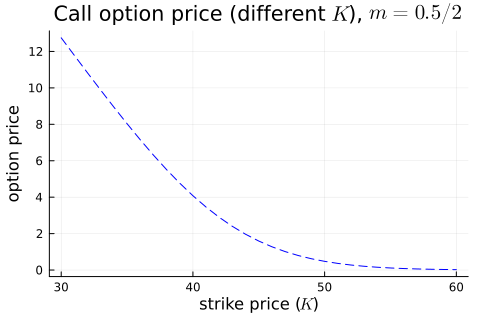

In [5]:
K_range = 30:60           #different strike prices
C_K     = OptionBlackSPs.(S,K_range,m,y,σ)          #m = 1/4

p1 = plot( K_range,C_K,
           linecolor = :blue,
           linestyle = :dash,
           legend = false,
           xticks = 30:10:60,
           title  = L"Call option price (different $K$), $m=%$m/2$",
           xlabel = L"strike price ($K$)",
           ylabel = "option price" )
display(p1)

# How the Black-Scholes Depends on Volatility

The Black-Scholes option price is an increasing function of the volatility ($\sigma$), as illustrated below.

## Implied Volatility

In the cell below we use an observed option price and solve the BS formula for $\sigma$. This is the "implied volatility," which could be interpreted as the market belief about (annualised) standard deviation of the underlying until expiration of the option. We do this for several option prices: the Black-Scholes price and also higher and lower prices.


### A Remark on the Code

- To solve for the implied volatility, the next cells use the [Roots.jl](https://github.com/JuliaMath/Roots.jl) package. 
- We solve for the root of the anonymous function `σ->OptionBlackSPs(S,K,m,y,σ)-C` which finds `σ` so that the model based price from `OptionBlackSPs()` minus the actual price `C` equals 0. We loop over a few different values of `C`.
- `iv = [... for Cᵢ in C_range]` creates a vector with one element per element in `C_range`.

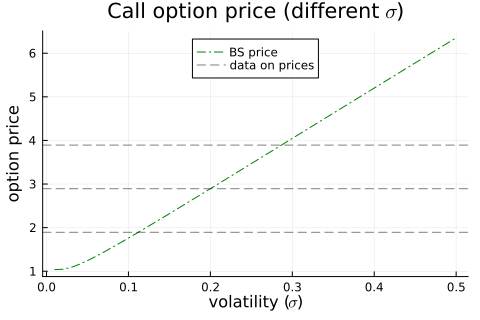

In [6]:
σ_range = 0.01:0.01:0.5           #S,K,m,y are scalars, σ_range is a vector
C_σ     = OptionBlackSPs.(S,K,m,y,σ_range)    #at different σ values
C_range = [C-1,C,C+1]          #cheaper,B-S price,expensive

p1 = plot( σ_range,C_σ,
           linecolor = :green,
           linestyle = :dashdot,
           label = "BS price",
           title = L"Call option price (different $\sigma$)",
           xlabel = L"volatility ($\sigma$)",
           ylabel = "option price",
           legend = :top )
hline!( C_range,linetype=:hline,linecolor=:black,line=(:dash,0.5),label="data on prices")
display(p1)

In [7]:
iv = [find_zero(σ->OptionBlackSPs(S,K,m,y,σ)-Cᵢ,(0,5)) for Cᵢ in C_range]  #create a vector of result,
                                                                           #for value in C_range
printblue("implied volatility:")
printmat(iv;rowNames=["Cheap option","Benchmark","Expensive option"])

printred("Compare the results with the previous graph\n")

implied volatility:
Cheap option         0.112
Benchmark            0.200
Expensive option     0.287

Compare the results with the previous graph



# BS from an Explicit Integration

The price of a European a call option is 

$C=e^{-ym}\text{E}^{\ast}\max(0,S_{m}-K),$

which can be written

$C=e^{-ym}\int_{K}^{\infty}\max(0,S_{m}-K)  f^{\ast}(S_{m})dS_{m},$

where $f^{\ast}(S_{m})$ is the risk neutral density function of the asset
price at expiration ($S_{m}$). The integration starts at $S_m=K$ since $\max(0,S_{m}-K)=0$ for $S_m<K$. See the figure below.

In the Black-Scholes model, the risk neutral distribution of $\ln S_{m}$ is

$\ln S_{m}\sim^{\ast}\text{N}(\ln S+my-m \sigma^{2}/2,m \sigma^2),$

where $S$ is the current asset price. This means that $f^{\ast}(S_m)$ is the pdf of a lognormally distributed variable. Notice that this is the pdf of $S_m$, not its logarithm.

### A Remark on the Code

- The `LogNormal` in the `Distributions.jl` package wants the mean and standard deviation of $\ln S_m$ as inputs, but calculates the pdf of $S_m$.
- The numerical integration is done by the [QuadGK.jl](https://github.com/JuliaMath/QuadGK.jl) package.
- The integration is of the anonymous function `x->BSintegrand(x,S,K,y,m,σ)` over the interval `[K,Inf]`. Here, `x` represents possible values of $S_m$.

In [8]:
"""
BSintegrand(Sₘ,S,K,y,m,σ)

Constructs the integrand for the Black-Scholes call price
"""

function BSintegrand(Sₘ,S,K,y,m,σ)
    μ = log(S) + m*y - m*σ^2/2            #"mean"
    λ = sqrt(m)*σ                         #"std"
    f = pdf(LogNormal(μ,λ),Sₘ)            #log-normal pdf(mean,std)
    z = exp(-y*m)*max(0,Sₘ-K)*f
    return z
end

BSintegrand (generic function with 1 method)

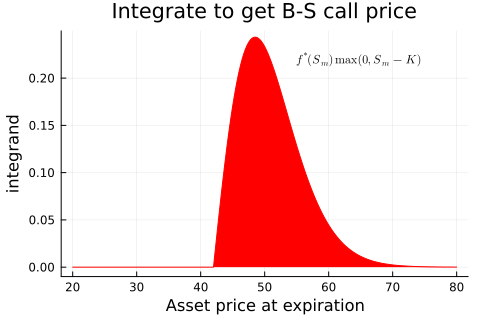

In [9]:
Sₘ_range = 20:0.25:80       #possible outcomes of underlying price

#txt = text("pdf * payoff",8,:left)
txt = text(L"f^\ast(S_m) \max(0,S_m-K)",8,:left)

p1 = plot( Sₘ_range,BSintegrand.(Sₘ_range,S,K,y,m,σ),
           linecolor = :red,
           ylim = (-0.01,0.25),
           fill = (0,:red),
           legend = false,
           title = "Integrate to get B-S call price",
           xlabel = "Asset price at expiration",
           ylabel = "integrand",
           annotation = (55,0.22,txt) )
display(p1)

In [10]:
C1, = QuadGK.quadgk(x->BSintegrand(x,S,K,y,m,σ),K,Inf)    #numerical integration over (K,Inf)

printblue("Call option price:")
printmat([C1,C],rowNames=["from numerical integration","from BS formula"])

Call option price:
from numerical integration     2.893
from BS formula                2.893



# Convergence of BOPM to BS

The next few cells calculate the option price according to binomial model with a CRR calibration where

$u=e^{\sigma\sqrt{h}}, d=e^{-\sigma\sqrt{h}} \text{ and } p=\frac{e^{yh}-d}{u-d}.$

This is done repeatedly, using more and more time steps ($n$) with $h=m/n$ where $m$ is the fixed time to expiration.

The file included below contains, among other things, the functions `BuildSTree()` and `EuOptionPrice()` from the chapter on the binomial model.

In [11]:
using OffsetArrays
include("src/OptionsCalculations.jl");

In [12]:
#(S,K,m,y,σ) = (42,42,0.5,0.05,0.2)       #these parameters were defined before

nMax = 50

C_bopm = fill(NaN,nMax)
for n in 1:nMax                         #calculate option price nMax times
    #local h, u, d, p, STree, Ce        #local/global is needed in script
    (h,u,d,p) = CRRparams(σ,m,y,n)
    STree     = BuildSTree(S,n,u,d)
    Ce        = EuOptionPrice(STree,K,y,h,p)
    C_bopm[n] = only(Ce[0])             #pick out the call price at the starting node, make it scalar
end

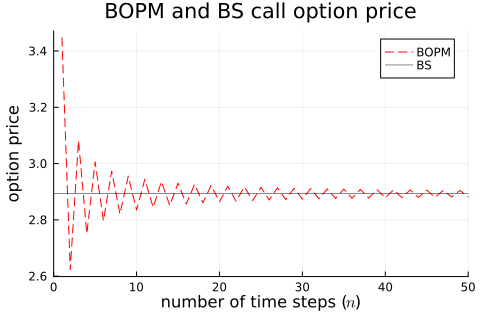

In [13]:
p1 = plot( 1:nMax,C_bopm,
           linecolor = :red,
           linestyle = :dash,
           linewidth = 1,
           xlims = [0,nMax],
           label = "BOPM",
           title = "BOPM and BS call option price",
           xlabel = L"number of time steps ($n$)",
           ylabel = "option price",
           annotation = (170,2.7,text(L"h = m/n",8)) )
hline!([C],linecolor=:black,line=:solid,linewidth=0.5,label="BS")           
display(p1)